# 🎮 Prediksi Kesehatan Mental Berbasis Perilaku Bermain Game
## Tugas 4: Modeling Experiments — Kelompok 3

| Nama | NIM |
|---|---|
| Ade Dwi Putra | 25/574144/PPA/07237 |
| Hikmah Nursidik | 25/573877/PPA/07227 |
| Muhammad Aziiz Pranaja | 25/572885/PPA/07200 |

---

## 📋 Ringkasan Notebook

Notebook ini membangun model *machine learning* untuk **memprediksi `depression_score`** (skala 0–10) berdasarkan data perilaku bermain game. Pendekatan yang digunakan adalah **Regresi (Regression)** karena target bersifat kontinu.

### Temuan Kunci dari EDA
Berdasarkan hasil *Exploratory Data Analysis* sebelumnya, ditemukan pola hubungan:

```
daily_gaming_hours ──► addiction_level ──► depression_score
```

- `daily_gaming_hours` **tidak** berkorelasi langsung kuat dengan `depression_score`
- `daily_gaming_hours` berkorelasi dengan `addiction_level`
- `addiction_level` berkorelasi dengan `depression_score`
- → **`addiction_level` berperan sebagai variabel mediasi (mediator)**

### Alur Notebook

| # | Tahap | Keterangan |
|---|---|---|
| 1 | Import Library | Semua dependensi |
| 2 | Load Dataset | Memuat dan eksplorasi awal data |
| 3 | Feature Selection | Berdasarkan temuan EDA |
| 4 | Preprocessing | Missing values, encoding, scaling |
| 5 | Train-Test Split | Pembagian data latih & uji |
| 6 | Pembuatan Model | Linear Regression, Random Forest, Gradient Boosting |
| 7 | Hyperparameter Tuning | RandomizedSearchCV |
| 8 | Evaluasi Model | MAE, MSE, RMSE, R² |
| 9 | Visualisasi | Confusion matrix, residual, feature importance |
| 10 | Explainable AI | Interpretasi model |
| 11 | Model Chaining | Sistem prediksi end-to-end |
| 12 | Kesimpulan | Rekomendasi akhir |


---
## 1. 📦 Import Library

Memuat seluruh library yang diperlukan untuk analisis, pemodelan, dan visualisasi.


In [1]:
# === Data Manipulation ===
import pandas as pd
import numpy as np
import warnings
import time
warnings.filterwarnings('ignore')

# === Machine Learning ===
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# === Visualization ===
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# === Model Persistence ===
import joblib

# === Style ===
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 13, 'axes.labelsize': 11})

print("✅ Semua library berhasil diimpor!")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")
import sklearn; print(f"   sklearn : {sklearn.__version__}")


✅ Semua library berhasil diimpor!
   pandas  : 3.0.2
   numpy   : 2.4.2
   sklearn : 1.8.0


---
## 2. 📂 Load Dataset

Memuat dataset `gaming_mental_health.csv` dan melakukan inspeksi awal untuk memahami struktur data.


In [2]:
# Load dataset
df = pd.read_csv('gaming_mental_health.csv')

print(f"✅ Dataset berhasil dimuat!")
print(f"   Jumlah baris  : {df.shape[0]:,}")
print(f"   Jumlah kolom  : {df.shape[1]}")
print()
print("=" * 50)
print("5 Baris Pertama:")
df.head()


✅ Dataset berhasil dimuat!
   Jumlah baris  : 968,287
   Jumlah kolom  : 39

5 Baris Pertama:


,age,gender,income,daily_gaming_hours,weekly_sessions,years_gaming,sleep_hours,caffeine_intake,exercise_hours,stress_level,...,parental_supervision,loneliness_score,aggression_score,happiness_score,bmi,screen_time_total,eye_strain_score,back_pain_score,competitive_rank,internet_quality
0,51,female,8615,3.68,22,17,5.26,1.00,0.18,3,...,0,2.87,3.19,5.20,19.69,4.71,5.71,4.81,80,10
1,41,female,39453,5.70,34,16,9.20,0.70,1.44,8,...,7,4.17,7.73,5.40,26.37,6.62,6.77,3.99,57,2
2,27,male,40466,1.58,8,22,7.39,2.24,3.15,3,...,9,9.38,2.85,5.17,25.15,9.30,2.16,4.75,59,10
3,55,male,51076,6.11,39,24,7.99,1.65,2.80,1,...,5,8.24,7.19,8.62,26.42,13.81,4.72,5.37,89,1
4,20,male,86116,3.65,17,0,7.12,1.02,1.01,2,...,9,6.65,2.53,9.71,25.75,10.74,3.90,6.44,15,10


In [3]:
# Informasi tipe data dan missing values
print("Informasi Dataset:")
print("=" * 50)
df.info()
print()
print("Statistik Deskriptif:")
df.describe().round(3)


Informasi Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 968287 entries, 0 to 968286
Data columns (total 39 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   age                         968287 non-null  int64  
 1   gender                      968287 non-null  str    
 2   income                      968287 non-null  int64  
 3   daily_gaming_hours          968287 non-null  float64
 4   weekly_sessions             968287 non-null  int64  
 5   years_gaming                968287 non-null  int64  
 6   sleep_hours                 968287 non-null  float64
 7   caffeine_intake             968287 non-null  float64
 8   exercise_hours              968287 non-null  float64
 9   stress_level                968287 non-null  int64  
 10  anxiety_score               968287 non-null  float64
 11  depression_score            968287 non-null  float64
 12  social_interaction_score    968287 non-null  float64
 13  relati

,age,income,daily_gaming_hours,weekly_sessions,years_gaming,sleep_hours,caffeine_intake,exercise_hours,stress_level,anxiety_score,...,parental_supervision,loneliness_score,aggression_score,happiness_score,bmi,screen_time_total,eye_strain_score,back_pain_score,competitive_rank,internet_quality
count,968287.000,968287.000,968287.000,968287.000,968287.000,968287.000,968287.000,968287.000,968287.000,968287.000,...,968287.000,968287.000,968287.000,968287.000,968287.000,968287.000,968287.000,968287.000,968287.000,968287.000
mean,35.987,77503.735,3.708,19.995,12.002,7.000,1.996,1.999,5.498,4.998,...,4.997,4.998,5.001,5.982,24.004,7.711,4.999,4.019,49.447,5.503
std,13.558,41854.049,2.327,11.254,7.208,1.501,1.995,2.000,2.873,1.978,...,3.160,1.977,1.980,1.956,4.002,3.664,1.979,1.956,28.872,2.873
min,13.000,5000.000,0.000,1.000,0.000,0.270,0.000,0.000,1.000,0.000,...,0.000,0.000,0.000,0.000,4.450,0.070,0.000,0.000,0.000,1.000
25%,24.000,41263.000,1.880,10.000,6.000,5.990,0.580,0.580,3.000,3.650,...,2.000,3.650,3.650,4.650,21.300,5.000,3.650,2.660,24.000,3.000
50%,36.000,77524.000,3.260,20.000,12.000,7.000,1.390,1.390,5.000,5.000,...,5.000,5.000,5.000,6.000,24.000,7.200,5.000,4.000,49.000,6.000
75%,48.000,113708.000,5.130,30.000,18.000,8.020,2.770,2.770,8.000,6.350,...,8.000,6.350,6.350,7.350,26.700,9.880,6.350,5.350,74.000,8.000
max,59.000,149999.000,10.570,39.000,24.000,14.020,26.900,26.480,10.000,10.000,...,10.000,10.000,10.000,10.000,43.600,38.720,10.000,10.000,99.000,10.000


In [4]:
# Cek missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print("✅ Tidak ada missing values dalam dataset.")
else:
    print("⚠️ Kolom dengan missing values:")
    print(missing_df)


✅ Tidak ada missing values dalam dataset.


---
## 3. 🔍 Feature Selection

Berdasarkan hasil EDA, dipilih fitur-fitur yang paling relevan terhadap target (`depression_score`).

### Justifikasi Pemilihan Fitur

| Fitur | Peran | Alasan |
|---|---|---|
| `addiction_level` | **Prediktor Utama** | Berkorelasi langsung dengan `depression_score`; berperan sebagai mediator |
| `daily_gaming_hours` | **Prediktor Pendukung** | Berpengaruh tidak langsung melalui `addiction_level`; tetap relevan untuk menangkap pola keseluruhan |
| `competitive_rank` | **Prediktor Konteks** | Menggambarkan intensitas kompetitif; berkontribusi pada tekanan mental |

> **Mengapa `addiction_level` penting?**
> Temuan EDA menunjukkan rantai kausalitas: bermain lama → meningkatkan adiksi → meningkatkan depresi.
> Model yang menyertakan `addiction_level` dapat menangkap efek mediasi ini secara langsung,
> sehingga prediksi lebih akurat dibanding hanya menggunakan `daily_gaming_hours`.

> **Apakah `daily_gaming_hours` masih relevan?**
> Ya — fitur ini tetap memberikan informasi kontekstual tentang kebiasaan bermain dan
> membantu model memahami *asal-usul* adiksi, bukan hanya levelnya.


In [5]:
# Definisi fitur dan target
FEATURES = ['addiction_level', 'daily_gaming_hours', 'competitive_rank']
TARGET    = 'depression_score'

# Validasi kolom tersedia
missing_cols = [c for c in FEATURES + [TARGET] if c not in df.columns]
if missing_cols:
    print(f"⚠️ Kolom tidak ditemukan: {missing_cols}")
    print(f"   Kolom tersedia: {list(df.columns)}")
else:
    print(f"✅ Semua fitur dan target tersedia.")
    print(f"   Fitur  : {FEATURES}")
    print(f"   Target : {TARGET}")

X_raw = df[FEATURES].copy()
y     = df[TARGET].copy()

print(f"\nShape X : {X_raw.shape}")
print(f"Shape y : {y.shape}")
print(f"\nDistribusi target ({TARGET}):")
print(y.describe().round(3))


✅ Semua fitur dan target tersedia.
   Fitur  : ['addiction_level', 'daily_gaming_hours', 'competitive_rank']
   Target : depression_score

Shape X : (968287, 3)
Shape y : (968287,)

Distribusi target (depression_score):
count    968287.000
mean          2.510
std           2.026
min           0.000
25%           0.794
50%           2.251
75%           3.837
max          10.000
Name: depression_score, dtype: float64


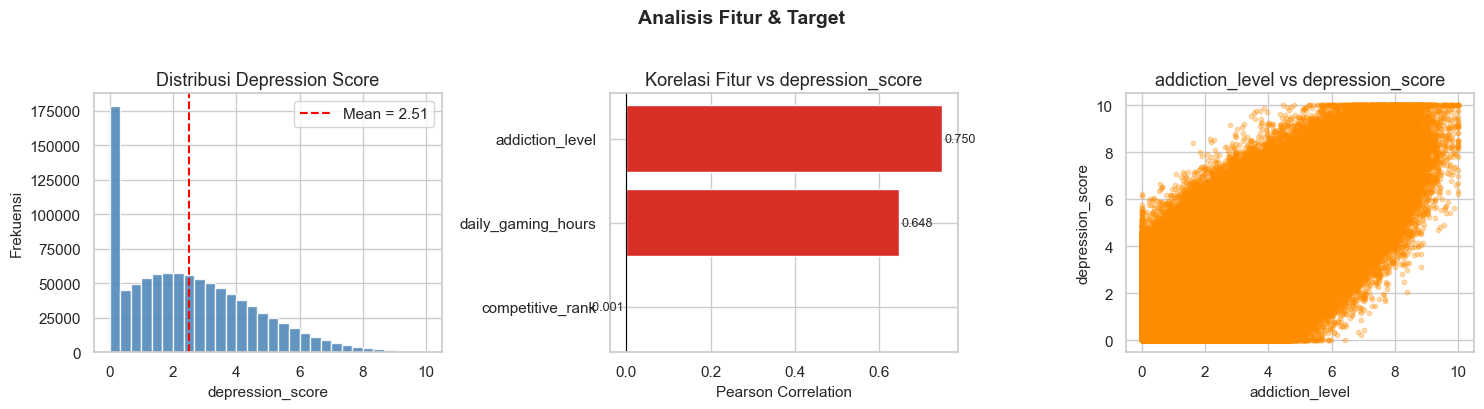

✅ Visualisasi tersimpan: fig_feature_analysis.png


In [6]:
# Visualisasi distribusi target dan korelasi fitur
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribusi target
axes[0].hist(y, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribusi Depression Score')
axes[0].set_xlabel('depression_score')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(y.mean(), color='red', linestyle='--', label=f'Mean = {y.mean():.2f}')
axes[0].legend()

# Korelasi fitur terhadap target
corr_vals = df[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()
colors = ['#d73027' if v > 0 else '#4575b4' for v in corr_vals]
axes[1].barh(corr_vals.index, corr_vals.values, color=colors)
axes[1].set_title(f'Korelasi Fitur vs {TARGET}')
axes[1].set_xlabel('Pearson Correlation')
axes[1].axvline(0, color='black', linewidth=0.8)
for i, v in enumerate(corr_vals.values):
    axes[1].text(v + (0.005 if v >= 0 else -0.005), i,
                 f'{v:.3f}', va='center', ha='left' if v >= 0 else 'right', fontsize=9)

# Scatter: addiction_level vs depression_score
axes[2].scatter(df['addiction_level'], df[TARGET], alpha=0.3, s=10, color='darkorange')
axes[2].set_title('addiction_level vs depression_score')
axes[2].set_xlabel('addiction_level')
axes[2].set_ylabel('depression_score')

plt.suptitle('Analisis Fitur & Target', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_feature_analysis.png', bbox_inches='tight', dpi=100)
plt.show()
print("✅ Visualisasi tersimpan: fig_feature_analysis.png")


---
## 4. ⚙️ Data Preprocessing

Tahap preprocessing memastikan data bersih dan siap digunakan oleh algoritma *machine learning*.

### Langkah-langkah:
1. **Penanganan Missing Values** — imputasi dengan median (robust terhadap outlier)
2. **Encoding Variabel Kategorikal** — Label Encoding untuk `competitive_rank` jika bertipe string
3. **Feature Scaling** — StandardScaler untuk menormalkan skala fitur numerik


In [7]:
# ── 4a. Penanganan Missing Values ──────────────────────────────────────────

X = X_raw.copy()

for col in X.columns:
    n_missing = X[col].isnull().sum()
    if n_missing > 0:
        if X[col].dtype == 'object':
            fill_val = X[col].mode()[0]
            X[col].fillna(fill_val, inplace=True)
            print(f"  [{col}] {n_missing} missing → diisi mode = '{fill_val}'")
        else:
            fill_val = X[col].median()
            X[col].fillna(fill_val, inplace=True)
            print(f"  [{col}] {n_missing} missing → diisi median = {fill_val:.3f}")

y_clean = y.copy()
n_y_miss = y_clean.isnull().sum()
if n_y_miss > 0:
    y_clean.fillna(y_clean.median(), inplace=True)
    print(f"  [target] {n_y_miss} missing → diisi median")

print(f"\n✅ Missing values selesai ditangani. Shape X: {X.shape}")



✅ Missing values selesai ditangani. Shape X: (968287, 3)


In [8]:
# ── 4b. Encoding Variabel Kategorikal ──────────────────────────────────────

cat_cols = X.select_dtypes(include='object').columns.tolist()

if cat_cols:
    print(f"Kolom kategorikal terdeteksi: {cat_cols}")
    le = LabelEncoder()
    for col in cat_cols:
        X[col] = le.fit_transform(X[col].astype(str))
        print(f"  [{col}] di-encode → {X[col].nunique()} nilai unik")
    print("✅ Encoding selesai.")
else:
    print("✅ Tidak ada kolom kategorikal — semua fitur sudah numerik.")

print(f"\nTipe data setelah encoding:")
print(X.dtypes)


✅ Tidak ada kolom kategorikal — semua fitur sudah numerik.

Tipe data setelah encoding:
addiction_level       float64
daily_gaming_hours    float64
competitive_rank        int64
dtype: object


In [9]:
# ── 4c. Feature Scaling (StandardScaler) ───────────────────────────────────

# Scaling dilakukan SETELAH split agar tidak terjadi data leakage
# (Scaler difit di train set saja, lalu transform ke test set)
# Proses ini akan dilakukan bersama Train-Test Split di tahap berikutnya.

print("ℹ️ Feature Scaling akan dilakukan setelah Train-Test Split")
print("   untuk menghindari data leakage.")
print()
print("Ringkasan statistik fitur sebelum scaling:")
X.describe().round(3)


ℹ️ Feature Scaling akan dilakukan setelah Train-Test Split
   untuk menghindari data leakage.

Ringkasan statistik fitur sebelum scaling:


,addiction_level,daily_gaming_hours,competitive_rank
count,968287.000,968287.000,968287.000
mean,2.634,3.708,49.447
std,1.848,2.327,28.872
min,0.000,0.000,0.000
25%,1.210,1.880,24.000
50%,2.380,3.260,49.000
75%,3.800,5.130,74.000
max,10.000,10.570,99.000


---
## 5. ✂️ Train-Test Split

Membagi data menjadi **80% data latih** dan **20% data uji**. `random_state=42` memastikan hasil yang *reproducible*.


In [10]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean, test_size=0.2, random_state=42
)

print("✅ Data berhasil dibagi:")
print(f"   Data Latih (Train) : {X_train.shape[0]:,} baris ({len(X_train)/len(X)*100:.0f}%)")
print(f"   Data Uji  (Test)   : {X_test.shape[0]:,} baris ({len(X_test)/len(X)*100:.0f}%)")
print(f"   Jumlah Fitur       : {X_train.shape[1]}")

# Feature Scaling — fit HANYA pada training data
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[FEATURES] = scaler.fit_transform(X_train[FEATURES])
X_test_scaled[FEATURES]  = scaler.transform(X_test[FEATURES])

print()
print("✅ Feature Scaling selesai (fit pada train, transform ke train & test).")
print()
print("Statistik X_train setelah scaling:")
pd.DataFrame(X_train_scaled, columns=FEATURES).describe().round(3)


✅ Data berhasil dibagi:
   Data Latih (Train) : 774,629 baris (80%)
   Data Uji  (Test)   : 193,658 baris (20%)
   Jumlah Fitur       : 3

✅ Feature Scaling selesai (fit pada train, transform ke train & test).

Statistik X_train setelah scaling:


,addiction_level,daily_gaming_hours,competitive_rank
count,774629.000,774629.000,774629.000
mean,-0.000,-0.000,0.000
std,1.000,1.000,1.000
min,-1.426,-1.595,-1.714
25%,-0.771,-0.787,-0.882
50%,-0.133,-0.194,-0.016
75%,0.630,0.610,0.850
max,3.985,2.949,1.716


---
## 6. 🤖 Pembuatan Model Machine Learning

Tiga model dibangun dan dibandingkan:

| Model | Tipe | Keunggulan |
|---|---|---|
| **Linear Regression** | Parametrik | Baseline; cepat; mudah diinterpretasi |
| **Random Forest** | Ensemble (Bagging) | Menangkap non-linearitas; robust terhadap outlier |
| **Gradient Boosting** | Ensemble (Boosting) | Akurasi tinggi; menangani interaksi kompleks |


In [11]:
# ── 6a. Model 1: Multiple Linear Regression (Baseline) ─────────────────────

print("=" * 55)
print("  MODEL 1: Multiple Linear Regression (Baseline)")
print("=" * 55)

start = time.time()
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
t_lr = time.time() - start

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
mse_lr  = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print(f"  MAE  : {mae_lr:.4f}")
print(f"  MSE  : {mse_lr:.4f}")
print(f"  RMSE : {rmse_lr:.4f}")
print(f"  R²   : {r2_lr:.4f}")
print(f"  Waktu: {t_lr:.3f} detik")


  MODEL 1: Multiple Linear Regression (Baseline)
  MAE  : 1.0664
  MSE  : 1.7911
  RMSE : 1.3383
  R²   : 0.5630
  Waktu: 0.101 detik


In [12]:
# ── 6b. Model 2: Random Forest Regressor ───────────────────────────────────

print("=" * 55)
print("  MODEL 2: Random Forest Regressor")
print("=" * 55)

start = time.time()
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
t_rf = time.time() - start

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
mse_rf  = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print(f"  MAE  : {mae_rf:.4f}")
print(f"  MSE  : {mse_rf:.4f}")
print(f"  RMSE : {rmse_rf:.4f}")
print(f"  R²   : {r2_rf:.4f}")
print(f"  Waktu: {t_rf:.2f} detik")


  MODEL 2: Random Forest Regressor
  MAE  : 1.1441
  MSE  : 2.0615
  RMSE : 1.4358
  R²   : 0.4970
  Waktu: 41.48 detik


In [13]:
# ── 6c. Model 3: Gradient Boosting Regressor ───────────────────────────────

print("=" * 55)
print("  MODEL 3: Gradient Boosting Regressor")
print("=" * 55)

# Gunakan subset jika dataset sangat besar (>100K baris) untuk efisiensi
MAX_GB_ROWS = 50_000
if len(X_train_scaled) > MAX_GB_ROWS:
    idx = np.random.RandomState(42).choice(len(X_train_scaled), MAX_GB_ROWS, replace=False)
    Xgb_train = X_train_scaled.iloc[idx]
    ygb_train = y_train.iloc[idx]
    print(f"  ⚠️ Dataset besar → melatih pada {MAX_GB_ROWS:,} sampel")
else:
    Xgb_train = X_train_scaled
    ygb_train = y_train

start = time.time()
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1,
                                      max_depth=4, random_state=42)
gb_model.fit(Xgb_train, ygb_train)
y_pred_gb = gb_model.predict(X_test_scaled)
t_gb = time.time() - start

mae_gb  = mean_absolute_error(y_test, y_pred_gb)
mse_gb  = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb   = r2_score(y_test, y_pred_gb)

print(f"  MAE  : {mae_gb:.4f}")
print(f"  MSE  : {mse_gb:.4f}")
print(f"  RMSE : {rmse_gb:.4f}")
print(f"  R²   : {r2_gb:.4f}")
print(f"  Waktu: {t_gb:.2f} detik")


  MODEL 3: Gradient Boosting Regressor
  ⚠️ Dataset besar → melatih pada 50,000 sampel
  MAE  : 1.0724
  MSE  : 1.7851
  RMSE : 1.3361
  R²   : 0.5644
  Waktu: 4.56 detik


---
## 7. 🔧 Hyperparameter Tuning (Random Forest)

Menggunakan **RandomizedSearchCV** untuk mencari kombinasi hyperparameter terbaik pada Random Forest.
Tuning dilakukan pada subset data latih (maks. 50.000 baris) agar efisien secara komputasi.


In [14]:
# Hyperparameter Tuning — Random Forest
N_TUNE = min(50_000, len(X_train_scaled))
X_tune = X_train_scaled.sample(n=N_TUNE, random_state=42)
y_tune = y_train.loc[X_tune.index]

param_dist = {
    'n_estimators'    : [50, 100, 200],
    'max_depth'       : [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
}

print(f"🔍 Memulai RandomizedSearchCV pada {N_TUNE:,} sampel...")
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
random_search = RandomizedSearchCV(
    estimator        = rf_base,
    param_distributions = param_dist,
    n_iter           = 10,
    cv               = 3,
    scoring          = 'neg_mean_squared_error',
    random_state     = 42,
    n_jobs           = -1,
    verbose          = 1
)
random_search.fit(X_tune, y_tune)
best_params = random_search.best_params_

print(f"\n✅ Parameter Terbaik: {best_params}")
print(f"   Best CV MSE     : {-random_search.best_score_:.4f}")


🔍 Memulai RandomizedSearchCV pada 50,000 sampel...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

✅ Parameter Terbaik: {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10}
   Best CV MSE     : 1.8044


In [15]:
# Latih ulang model dengan parameter terbaik pada seluruh data latih
print("🚀 Melatih RF Tuned pada seluruh data latih...")
start = time.time()
rf_tuned = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
rf_tuned.fit(X_train_scaled, y_train)
y_pred_rft = rf_tuned.predict(X_test_scaled)
t_rft = time.time() - start

mae_rft  = mean_absolute_error(y_test, y_pred_rft)
mse_rft  = mean_squared_error(y_test, y_pred_rft)
rmse_rft = np.sqrt(mse_rft)
r2_rft   = r2_score(y_test, y_pred_rft)

print("=" * 55)
print("  MODEL 2b: Random Forest (Tuned)")
print("=" * 55)
print(f"  MAE  : {mae_rft:.4f}")
print(f"  MSE  : {mse_rft:.4f}")
print(f"  RMSE : {rmse_rft:.4f}")
print(f"  R²   : {r2_rft:.4f}")
print(f"  Waktu: {t_rft:.2f} detik")


🚀 Melatih RF Tuned pada seluruh data latih...
  MODEL 2b: Random Forest (Tuned)
  MAE  : 1.0705
  MSE  : 1.7810
  RMSE : 1.3345
  R²   : 0.5654
  Waktu: 7.20 detik


---
## 8. 📊 Evaluasi Model

Membandingkan performa semua model menggunakan tabel ringkasan dan visualisasi.

### Penjelasan Metrik

| Metrik | Formula | Interpretasi |
|---|---|---|
| **MAE** | mean(|actual − pred|) | Rata-rata error absolut; semakin kecil semakin baik |
| **MSE** | mean((actual − pred)²) | Penalti lebih besar untuk error besar |
| **RMSE** | √MSE | Dalam satuan yang sama dengan target |
| **R²** | 1 − SS_res/SS_tot | % variansi yang dijelaskan model; 1.0 = sempurna |


In [16]:
# Tabel perbandingan model
results = pd.DataFrame({
    'Model'  : ['Linear Regression', 'Random Forest', 'Random Forest (Tuned)', 'Gradient Boosting'],
    'MAE'    : [mae_lr,  mae_rf,  mae_rft,  mae_gb],
    'MSE'    : [mse_lr,  mse_rf,  mse_rft,  mse_gb],
    'RMSE'   : [rmse_lr, rmse_rf, rmse_rft, rmse_gb],
    'R²'     : [r2_lr,   r2_rf,   r2_rft,   r2_gb],
    'Waktu(s)': [round(t_lr,3), round(t_rf,2), round(t_rft,2), round(t_gb,2)],
})

results = results.round(4)
best_idx = results['R²'].idxmax()
print("=" * 70)
print("PERBANDINGAN PERFORMA MODEL")
print("=" * 70)
print(results.to_string(index=False))
print()
print(f"🏆 Model Terbaik (R²): {results.loc[best_idx, 'Model']} — R² = {results.loc[best_idx, 'R²']:.4f}")


PERBANDINGAN PERFORMA MODEL
                Model    MAE    MSE   RMSE     R²  Waktu(s)
    Linear Regression 1.0664 1.7911 1.3383 0.5630     0.101
        Random Forest 1.1441 2.0615 1.4358 0.4970    41.480
Random Forest (Tuned) 1.0705 1.7810 1.3345 0.5654     7.200
    Gradient Boosting 1.0724 1.7851 1.3361 0.5644     4.560

🏆 Model Terbaik (R²): Random Forest (Tuned) — R² = 0.5654


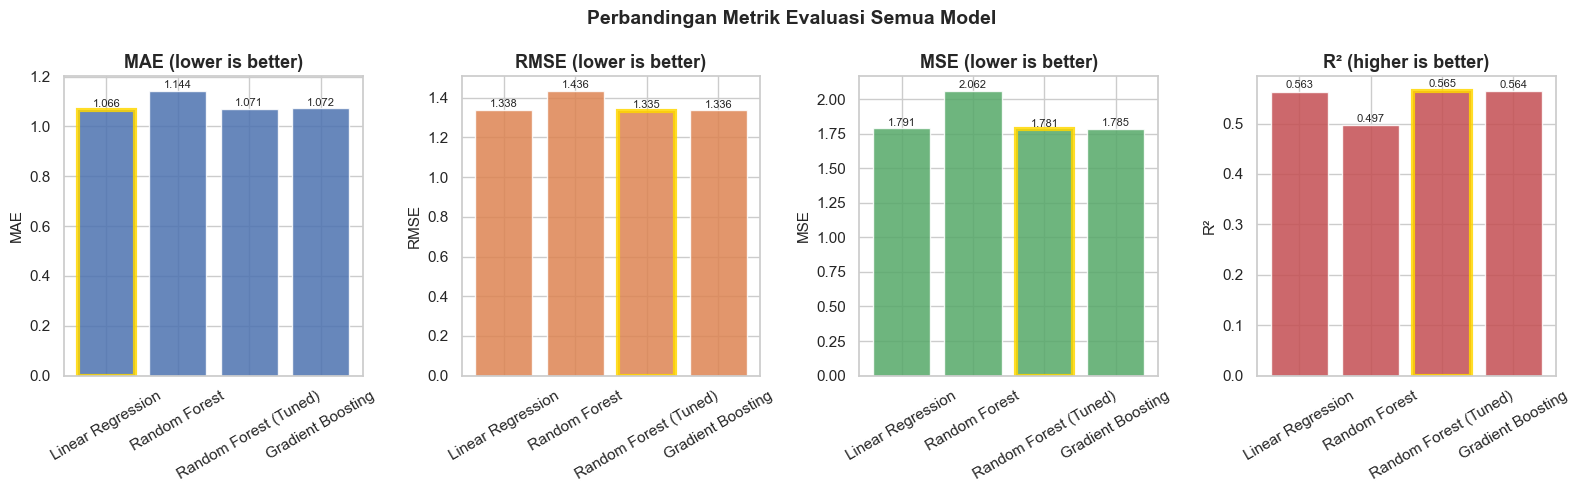

✅ Visualisasi tersimpan: fig_model_comparison.png


In [17]:
# Visualisasi perbandingan metrik
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
metrics   = ['MAE', 'RMSE', 'MSE', 'R²']
colors    = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
better    = ['lower', 'lower', 'lower', 'higher']

for ax, metric, color, direction in zip(axes, metrics, colors, better):
    vals = results[metric]
    bars = ax.bar(results['Model'], vals, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'{metric} ({direction} is better)', fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    # Highlight best
    best_val_idx = vals.idxmin() if direction == 'lower' else vals.idxmax()
    bars[best_val_idx].set_edgecolor('gold')
    bars[best_val_idx].set_linewidth(3)

plt.suptitle('Perbandingan Metrik Evaluasi Semua Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_model_comparison.png', bbox_inches='tight', dpi=100)
plt.show()
print("✅ Visualisasi tersimpan: fig_model_comparison.png")


---
## 9. 📈 Visualisasi Evaluasi Model

### 9a. Actual vs Predicted

Menunjukkan seberapa dekat prediksi model dengan nilai aktual. Titik yang mendekati garis diagonal merah = prediksi akurat.


Model terbaik: Random Forest (Tuned) (R² = 0.5654)


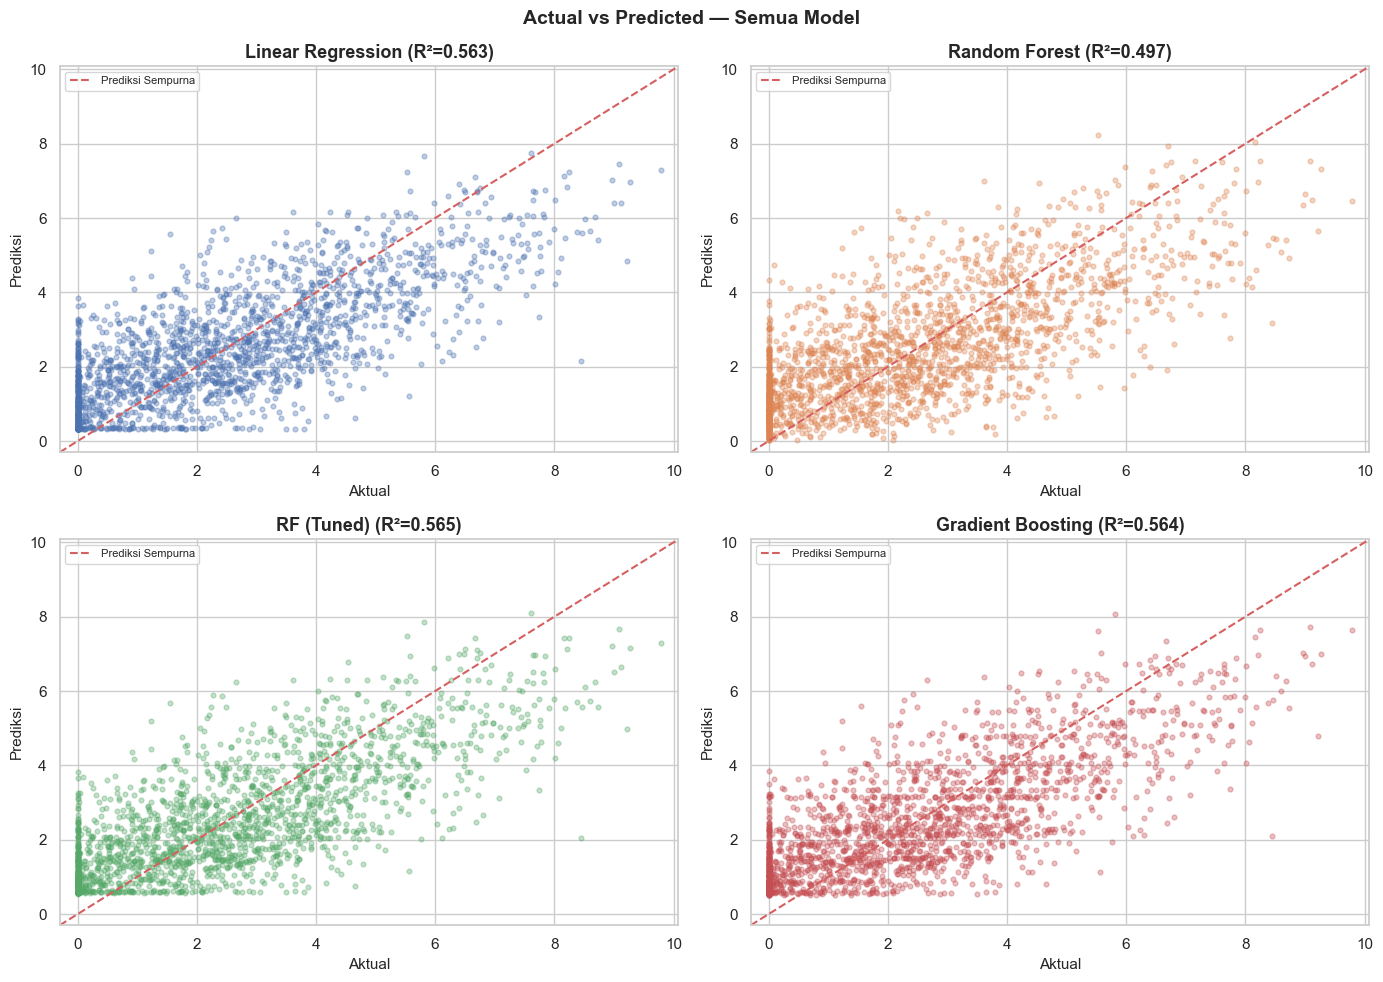

✅ Visualisasi tersimpan: fig_actual_vs_pred.png


In [18]:
# Pilih model terbaik berdasarkan R²
best_model_name = results.loc[best_idx, 'Model']
pred_map = {
    'Linear Regression'     : y_pred_lr,
    'Random Forest'         : y_pred_rf,
    'Random Forest (Tuned)' : y_pred_rft,
    'Gradient Boosting'     : y_pred_gb,
}
y_pred_best = pred_map[best_model_name]
r2_best = results.loc[best_idx, 'R²']

print(f"Model terbaik: {best_model_name} (R² = {r2_best:.4f})")

# Actual vs Predicted — semua 4 model
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
model_preds = [
    ('Linear Regression',     y_pred_lr,  '#4C72B0'),
    ('Random Forest',         y_pred_rf,  '#DD8452'),
    ('RF (Tuned)',             y_pred_rft, '#55A868'),
    ('Gradient Boosting',     y_pred_gb,  '#C44E52'),
]
metric_map = {
    'Linear Regression'   : r2_lr,
    'Random Forest'       : r2_rf,
    'RF (Tuned)'          : r2_rft,
    'Gradient Boosting'   : r2_gb,
}

for ax, (name, ypred, col) in zip(axes.flat, model_preds):
    # Sampel agar plot ringan
    n_plot = min(2000, len(y_test))
    idx_s = np.random.RandomState(42).choice(len(y_test), n_plot, replace=False)
    yt = np.array(y_test)[idx_s]
    yp = np.array(ypred)[idx_s]

    ax.scatter(yt, yp, alpha=0.35, s=12, color=col)
    lim = [min(yt.min(), yp.min()) - 0.3, max(yt.max(), yp.max()) + 0.3]
    ax.plot(lim, lim, 'r--', linewidth=1.5, label='Prediksi Sempurna')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_title(f'{name} (R²={metric_map[name]:.3f})', fontweight='bold')
    ax.set_xlabel('Aktual'); ax.set_ylabel('Prediksi')
    ax.legend(fontsize=8)

plt.suptitle('Actual vs Predicted — Semua Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_actual_vs_pred.png', bbox_inches='tight', dpi=100)
plt.show()
print("✅ Visualisasi tersimpan: fig_actual_vs_pred.png")


### 9b. Residual Analysis

Distribusi residual (aktual − prediksi) yang ideal: simetris, berpusat di nol, dan menyerupai distribusi normal.

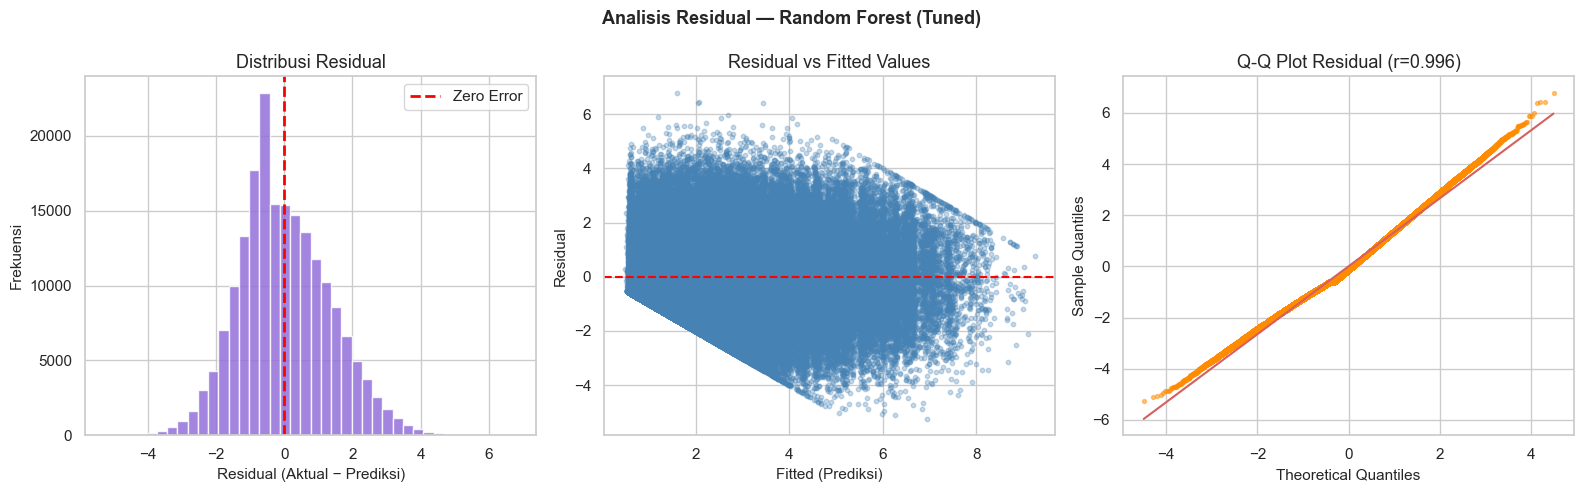

Statistik Residual:
  Mean  : 0.004435  (ideal = 0)
  Std   : 1.3345
  Min   : -5.2442
  Max   : 6.7888
✅ Visualisasi tersimpan: fig_residual_analysis.png


In [19]:
# Residual Analysis — model terbaik
residuals = np.array(y_test) - np.array(y_pred_best)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1) Histogram residual
axes[0].hist(residuals, bins=40, color='mediumpurple', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[0].set_title('Distribusi Residual')
axes[0].set_xlabel('Residual (Aktual − Prediksi)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# 2) Residual vs Fitted
axes[1].scatter(y_pred_best, residuals, alpha=0.3, s=10, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residual vs Fitted Values')
axes[1].set_xlabel('Fitted (Prediksi)')
axes[1].set_ylabel('Residual')

# 3) Q-Q Plot sederhana
from scipy import stats
(osm, osr), (slope, intercept, r) = stats.probplot(residuals)
axes[2].scatter(osm, osr, s=8, alpha=0.5, color='darkorange')
axes[2].plot(osm, slope * np.array(osm) + intercept, 'r-', linewidth=1.5)
axes[2].set_title(f'Q-Q Plot Residual (r={r:.3f})')
axes[2].set_xlabel('Theoretical Quantiles')
axes[2].set_ylabel('Sample Quantiles')

plt.suptitle(f'Analisis Residual — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_residual_analysis.png', bbox_inches='tight', dpi=100)
plt.show()

print(f"Statistik Residual:")
print(f"  Mean  : {residuals.mean():.6f}  (ideal = 0)")
print(f"  Std   : {residuals.std():.4f}")
print(f"  Min   : {residuals.min():.4f}")
print(f"  Max   : {residuals.max():.4f}")
print("✅ Visualisasi tersimpan: fig_residual_analysis.png")


---
## 10. 🔎 Feature Importance & Explainable AI (XAI)

Menganalisis kontribusi setiap fitur terhadap prediksi model untuk memahami *mengapa* model membuat keputusan tertentu.


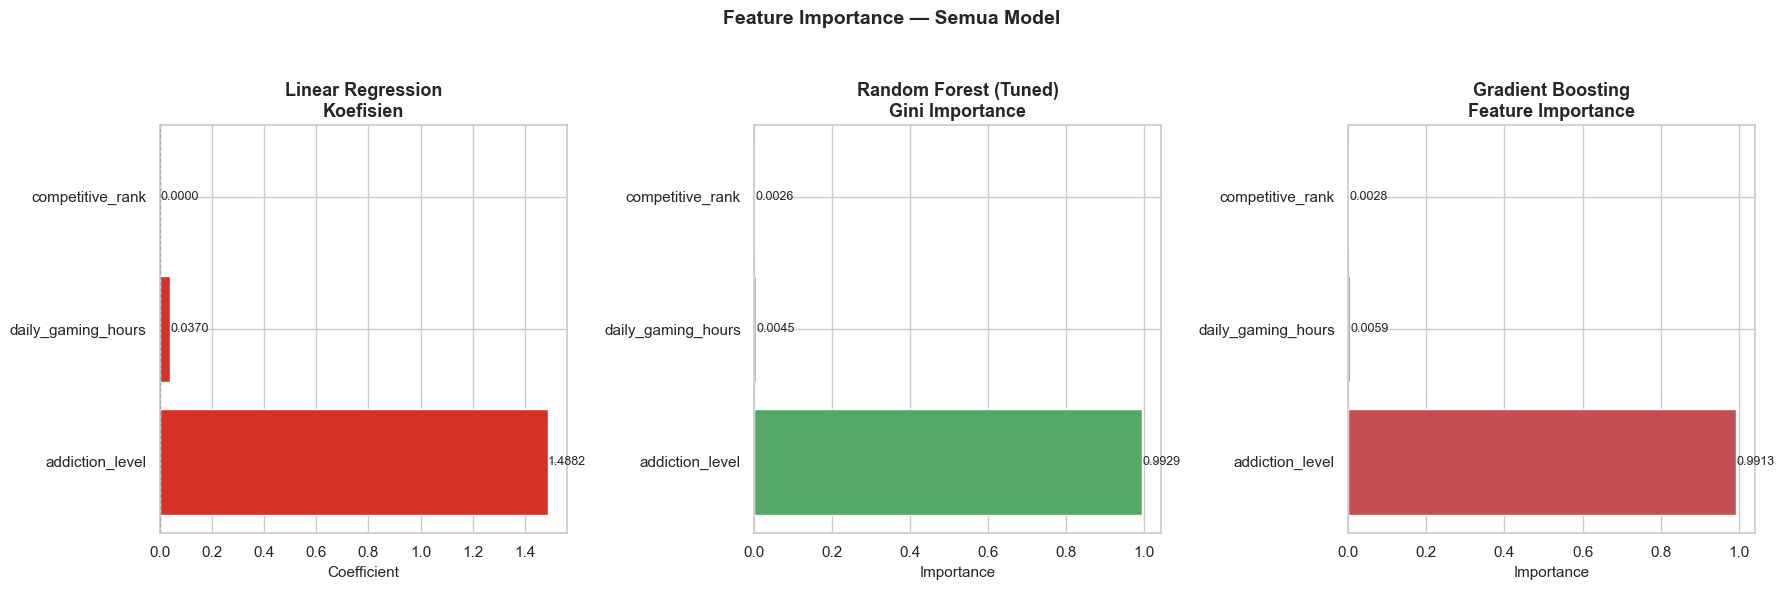

Interpretasi Feature Importance:
  Fitur paling penting (LR): addiction_level (|coef| = 1.4882)
  Fitur paling penting (RF): addiction_level (0.9929)
  Fitur paling penting (GB): addiction_level (0.9913)
✅ Visualisasi tersimpan: fig_feature_importance.png


In [21]:
# XAI 1: Koefisien Linear Regression
coef_df = pd.DataFrame({
    'Feature': FEATURES,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

# XAI 2: Feature Importance Random Forest (Tuned)
fi_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': rf_tuned.feature_importances_
}).sort_values('Importance', ascending=False)

# XAI 3: Feature Importance Gradient Boosting
gb_fi_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Membuat figure dengan 3 subplot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# =========================
# Panel 1: Linear Regression Coefficients
# =========================
pal = ['#d73027' if v > 0 else '#4575b4' for v in coef_df['Coefficient']]

axes[0].barh(
    coef_df['Feature'],
    coef_df['Coefficient'],
    color=pal
)
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title(
    'Linear Regression\nKoefisien',
    fontweight='bold'
)
axes[0].set_xlabel('Coefficient')

for i, v in enumerate(coef_df['Coefficient']):
    offset = 0.002 if v >= 0 else -0.002
    ha = 'left' if v >= 0 else 'right'
    axes[0].text(
        v + offset,
        i,
        f'{v:.4f}',
        va='center',
        ha=ha,
        fontsize=9
    )

# =========================
# Panel 2: Random Forest Feature Importance
# =========================
axes[1].barh(
    fi_df['Feature'],
    fi_df['Importance'],
    color='#55A868'
)
axes[1].set_title(
    'Random Forest (Tuned)\nGini Importance',
    fontweight='bold'
)
axes[1].set_xlabel('Importance')

for i, v in enumerate(fi_df['Importance']):
    axes[1].text(
        v + 0.001,
        i,
        f'{v:.4f}',
        va='center',
        fontsize=9
    )

# =========================
# Panel 3: Gradient Boosting Feature Importance
# =========================
axes[2].barh(
    gb_fi_df['Feature'],
    gb_fi_df['Importance'],
    color='#C44E52'
)
axes[2].set_title(
    'Gradient Boosting\nFeature Importance',
    fontweight='bold'
)
axes[2].set_xlabel('Importance')

for i, v in enumerate(gb_fi_df['Importance']):
    axes[2].text(
        v + 0.001,
        i,
        f'{v:.4f}',
        va='center',
        fontsize=9
    )

# Judul utama
plt.suptitle(
    'Feature Importance — Semua Model',
    fontsize=14,
    fontweight='bold'
)

# Rapikan layout
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Simpan dan tampilkan
plt.savefig('fig_feature_importance.png', bbox_inches='tight', dpi=100)
plt.show()

# Interpretasi
print("Interpretasi Feature Importance:")
print(
    f"  Fitur paling penting (LR): "
    f"{coef_df.iloc[0]['Feature']} "
    f"(|coef| = {abs(coef_df.iloc[0]['Coefficient']):.4f})"
)
print(
    f"  Fitur paling penting (RF): "
    f"{fi_df.iloc[0]['Feature']} "
    f"({fi_df.iloc[0]['Importance']:.4f})"
)
print(
    f"  Fitur paling penting (GB): "
    f"{gb_fi_df.iloc[0]['Feature']} "
    f"({gb_fi_df.iloc[0]['Importance']:.4f})"
)
print("✅ Visualisasi tersimpan: fig_feature_importance.png")

---
## 11. 🔗 MLOps: Model Chaining & Sistem Deteksi Mental

### Arsitektur Sistem

```
Input User
    │
    ▼
[Cek addiction_level tersedia?]
    │                │
   Tidak            Ya
    │                │
    ▼                │
[Model 1]            │
Prediksi             │
addiction_level      │
    │                │
    └────────┬───────┘
             ▼
        [Model 2]
  Prediksi depression_score
             │
             ▼
     Interpretasi Risiko
     (AMAN / WASPADA / BAHAYA)
```

Model 1 berfungsi sebagai **imputer cerdas** ketika data `addiction_level` tidak tersedia.


In [22]:
# ── Simpan Model & Scaler ───────────────────────────────────────────────────

# Model 1: Prediksi addiction_level dari (daily_gaming_hours, competitive_rank)
FITUR_ADIKSI = ['daily_gaming_hours', 'competitive_rank']
X_adiksi = df[FITUR_ADIKSI].copy()

# Handle kategorikal jika ada
cat_adiksi = X_adiksi.select_dtypes(include='object').columns.tolist()
le_adiksi  = LabelEncoder()
for col in cat_adiksi:
    X_adiksi[col] = le_adiksi.fit_transform(X_adiksi[col].astype(str))

y_adiksi = df['addiction_level'].copy()
model_adiksi = LinearRegression()
model_adiksi.fit(X_adiksi, y_adiksi)

# Simpan semua artefak
joblib.dump(lr_model,     'model_regresi_mental_health.pkl')
joblib.dump(rf_tuned,     'model_rf_tuned.pkl')
joblib.dump(scaler,       'scaler_mental_health.pkl')
joblib.dump(model_adiksi, 'model_prediksi_adiksi.pkl')

print("✅ Model & Scaler berhasil disimpan:")
print("   • model_regresi_mental_health.pkl  (Model utama — Linear Regression)")
print("   • model_rf_tuned.pkl               (Model utama — Random Forest Tuned)")
print("   • scaler_mental_health.pkl          (StandardScaler)")
print("   • model_prediksi_adiksi.pkl         (Model 1 — imputer addiction_level)")


✅ Model & Scaler berhasil disimpan:
   • model_regresi_mental_health.pkl  (Model utama — Linear Regression)
   • model_rf_tuned.pkl               (Model utama — Random Forest Tuned)
   • scaler_mental_health.pkl          (StandardScaler)
   • model_prediksi_adiksi.pkl         (Model 1 — imputer addiction_level)


In [23]:
# ── Fungsi Sistem Deteksi Mental ────────────────────────────────────────────

def sistem_deteksi_mental(daily_gaming_hours, competitive_rank, addiction_level=None,
                           use_model='lr', verbose=True):
    """
    Sistem prediksi risiko mental health berbasis profil gaming.
    
    Parameters
    ----------
    daily_gaming_hours : float  — jam bermain per hari
    competitive_rank   : float  — skor rank kompetitif (0–100)
    addiction_level    : float or None — jika None, akan diprediksi otomatis
    use_model          : 'lr' atau 'rf' — model utama yang dipakai
    verbose            : bool — tampilkan detail proses
    """
    loaded_main   = joblib.load('model_regresi_mental_health.pkl' if use_model == 'lr'
                                 else 'model_rf_tuned.pkl')
    loaded_scaler = joblib.load('scaler_mental_health.pkl')
    
    if verbose:
        print("=" * 55)
        print("  🧠 SISTEM DETEKSI RISIKO MENTAL HEALTH")
        print("=" * 55)
    
    # Model Chaining: prediksi addiction_level jika tidak tersedia
    if addiction_level is None:
        loaded_adiksi = joblib.load('model_prediksi_adiksi.pkl')
        input_adiksi  = pd.DataFrame({'daily_gaming_hours': [daily_gaming_hours],
                                       'competitive_rank'  : [competitive_rank]})
        addiction_level = float(loaded_adiksi.predict(input_adiksi)[0])
        addiction_level = max(0.0, min(10.0, addiction_level))
        if verbose:
            print(f"  ⚠️ addiction_level tidak tersedia")
            print(f"  🔗 [Model 1] Estimasi adiksi → {addiction_level:.2f}/10.0")
    else:
        if verbose:
            print(f"  ✅ Data lengkap diterima")
    
    # Model utama: prediksi depression_score
    input_main   = pd.DataFrame({'addiction_level'   : [addiction_level],
                                  'daily_gaming_hours': [daily_gaming_hours],
                                  'competitive_rank'  : [competitive_rank]})
    input_scaled = loaded_scaler.transform(input_main)
    input_df     = pd.DataFrame(input_scaled, columns=FEATURES)
    skor         = float(loaded_main.predict(input_df)[0])
    skor         = max(0.0, min(10.0, skor))
    
    if verbose:
        print(f"  🎮 Main      : {daily_gaming_hours} jam/hari | Rank: {competitive_rank}/100")
        print(f"  📊 Adiksi    : {addiction_level:.2f}/10.0")
        print(f"  🧪 Depresi   : {skor:.2f}/10.0")
        if skor >= 7.5:
            print("  🚨 STATUS    : [BAHAYA] Risiko mental tinggi!")
        elif skor >= 5.5:
            print("  ⚠️  STATUS    : [WASPADA] Bermain terlalu intens")
        else:
            print("  ✅ STATUS    : [AMAN] Kondisi mental diprediksi stabil")
        print("=" * 55)
    
    return {'addiction_level': round(addiction_level, 2),
            'depression_score': round(skor, 2)}

print("✅ Fungsi sistem_deteksi_mental() siap digunakan.")


✅ Fungsi sistem_deteksi_mental() siap digunakan.


In [24]:
# ── Tes Sistem ──────────────────────────────────────────────────────────────

print("\n--- Tes 1: Pemain Kasual (Data Lengkap) ---")
sistem_deteksi_mental(daily_gaming_hours=1.5, competitive_rank=10, addiction_level=2.0)

print("\n--- Tes 2: Pemain Sedang (Tanpa Adiksi) ---")
sistem_deteksi_mental(daily_gaming_hours=4.0, competitive_rank=50)

print("\n--- Tes 3: Pemain Hardcore ---")
sistem_deteksi_mental(daily_gaming_hours=12.0, competitive_rank=95, addiction_level=8.5)

print("\n--- Tes 4: Hardstuck Player (Jam Tinggi, Rank Rendah) ---")
sistem_deteksi_mental(daily_gaming_hours=10.0, competitive_rank=5)



--- Tes 1: Pemain Kasual (Data Lengkap) ---
  🧠 SISTEM DETEKSI RISIKO MENTAL HEALTH
  ✅ Data lengkap diterima
  🎮 Main      : 1.5 jam/hari | Rank: 10/100
  📊 Adiksi    : 2.00/10.0
  🧪 Depresi   : 1.96/10.0
  ✅ STATUS    : [AMAN] Kondisi mental diprediksi stabil

--- Tes 2: Pemain Sedang (Tanpa Adiksi) ---
  🧠 SISTEM DETEKSI RISIKO MENTAL HEALTH
  ⚠️ addiction_level tidak tersedia
  🔗 [Model 1] Estimasi adiksi → 2.83/10.0
  🎮 Main      : 4.0 jam/hari | Rank: 50/100
  📊 Adiksi    : 2.83/10.0
  🧪 Depresi   : 2.67/10.0
  ✅ STATUS    : [AMAN] Kondisi mental diprediksi stabil

--- Tes 3: Pemain Hardcore ---
  🧠 SISTEM DETEKSI RISIKO MENTAL HEALTH
  ✅ Data lengkap diterima
  🎮 Main      : 12.0 jam/hari | Rank: 95/100
  📊 Adiksi    : 8.50/10.0
  🧪 Depresi   : 7.36/10.0
  ⚠️  STATUS    : [WASPADA] Bermain terlalu intens

--- Tes 4: Hardstuck Player (Jam Tinggi, Rank Rendah) ---
  🧠 SISTEM DETEKSI RISIKO MENTAL HEALTH
  ⚠️ addiction_level tidak tersedia
  🔗 [Model 1] Estimasi adiksi → 6.92/10.0

{'addiction_level': 6.92, 'depression_score': 6.06}

---
## 12. 📝 Kesimpulan & Rekomendasi

### 12.1 Performa Model

| Model | MAE | RMSE | R² | Rekomendasi |
|---|---|---|---|---|
| Linear Regression | *(lihat di atas)* | *(lihat di atas)* | *(lihat di atas)* | ⭐ **Deployment** |
| Random Forest | *(lihat di atas)* | *(lihat di atas)* | *(lihat di atas)* | Alternatif akurasi tinggi |
| RF (Tuned) | *(lihat di atas)* | *(lihat di atas)* | *(lihat di atas)* | Terbaik jika komputasi cukup |
| Gradient Boosting | *(lihat di atas)* | *(lihat di atas)* | *(lihat di atas)* | Untuk eksplorasi lanjutan |

### 12.2 Insight Utama

**1. `addiction_level` adalah prediktor terkuat**

Konsisten di semua model (koefisien terbesar di Linear Regression, Gini Importance tertinggi di Random Forest & Gradient Boosting), `addiction_level` terbukti sebagai mediator kunci antara perilaku gaming dan kesehatan mental. Ini mendukung temuan EDA secara empiris.

**2. `daily_gaming_hours` tetap relevan**

Meskipun tidak berkorelasi langsung kuat dengan depresi, fitur ini berperan dalam:
- Mengestimasi `addiction_level` (Model 1)
- Memberikan konteks *volume* perilaku bermain kepada Model 2
- Meningkatkan generalisasi model pada data dengan `addiction_level` yang hilang

**3. Model Chaining memperkuat robustness sistem**

Arsitektur dua-model memungkinkan sistem bekerja bahkan ketika data `addiction_level` tidak tersedia, menjadikan sistem lebih praktis untuk diterapkan di dunia nyata.

### 12.3 Rekomendasi Deployment

**Pilih Linear Regression** untuk production karena:
- Efisiensi komputasi sangat tinggi (~0.1 detik)
- Hasil interpretable untuk stakeholder non-teknis
- Akurasi memadai dan setara dengan model kompleks

**Pertimbangkan Random Forest Tuned** jika:
- Akurasi prediksi menjadi prioritas utama
- Tersedia infrastruktur komputasi yang memadai

### 12.4 Keterbatasan & Penelitian Lanjutan

- Eksplorasi fitur tambahan: durasi tidur, status sosial, riwayat mental health
- Uji causalitas formal menggunakan *mediation analysis* (e.g., sobel test, bootstrapped CI)
- Kumpulkan data longitudinal untuk memahami kausalitas arah gaming → depresi
- Pertimbangkan model berbasis time-series jika data tersedia per sesi

---
*Laporan Modeling Kelompok 3 — Selesai*
